# **第五部分：管制藥物、非法物質暴露與增肌類固醇濫用軌跡（Restricted Substances, Illicit Drug Exposure, and Anabolic Steroid Abuse Profiles）**

In [10]:
import os
import pandas as pd

# =========================================================================
# 1. 📂 載入同源基礎資料集
# =========================================================================
snapshot_path = '../data/processed/04_category1_weight_perception_control_clean.csv'
if os.path.exists(snapshot_path):
    df_debug = pd.read_csv(snapshot_path)
else:
    raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確認路徑。")

# =========================================================================
# 🔍 七大管制物質與藥物指標「底細與真實編碼」全面打撈器
# =========================================================================
target_cols = [
    'EverMarijuaUse', 
    'CurrentMarijuaUse', 
    'InitiationOfMarijuaUse', 
    'EverUsedLSD', 
    'IllegalInjectedDrugUse', 
    'EverSteriodUse', 
    'IllegalDrugsAtSchool'
]

print("=" * 70)
print("🎯 【七大管制物質與藥物指標 —— 真實編碼值與人頭分佈全面打撈】")
print("=" * 70)

for col in target_cols:
    if col in df_debug.columns:
        print(f"📋 欄位名稱: 【{col}】")
        print("-" * 50)
        # 使用 value_counts(dropna=False) 完整還原真實編碼（包含 NaN 的實質人數）
        counts = df_debug[col].value_counts(dropna=False)
        
        # 逐行輸出編碼狀況
        for val, count in counts.items():
            val_type = type(val).__name__
            print(f"  - 填答數值: {str(val):<10} (資料型態: {val_type:<6}) ➡️ 實質填答人數: {count:,} 筆")
    else:
        print(f"⚠️ [欄位警報] 您的資料集中找不到欄位: '{col}'，請檢查拼字。")
    print("=" * 70)

🎯 【七大管制物質與藥物指標 —— 真實編碼值與人頭分佈全面打撈】
📋 欄位名稱: 【EverMarijuaUse】
--------------------------------------------------
  - 填答數值: 1.0        (資料型態: float ) ➡️ 實質填答人數: 7,461 筆
  - 填答數值: 2.0        (資料型態: float ) ➡️ 實質填答人數: 1,278 筆
  - 填答數值: 7.0        (資料型態: float ) ➡️ 實質填答人數: 1,147 筆
  - 填答數值: 3.0        (資料型態: float ) ➡️ 實質填答人數: 1,073 筆
  - 填答數值: 4.0        (資料型態: float ) ➡️ 實質填答人數: 604 筆
  - 填答數值: 5.0        (資料型態: float ) ➡️ 實質填答人數: 583 筆
  - 填答數值: 6.0        (資料型態: float ) ➡️ 實質填答人數: 524 筆
  - 填答數值: nan        (資料型態: float ) ➡️ 實質填答人數: 324 筆
📋 欄位名稱: 【CurrentMarijuaUse】
--------------------------------------------------
  - 填答數值: 1.0        (資料型態: float ) ➡️ 實質填答人數: 10,040 筆
  - 填答數值: 2.0        (資料型態: float ) ➡️ 實質填答人數: 982 筆
  - 填答數值: 3.0        (資料型態: float ) ➡️ 實質填答人數: 604 筆
  - 填答數值: 6.0        (資料型態: float ) ➡️ 實質填答人數: 449 筆
  - 填答數值: 4.0        (資料型態: float ) ➡️ 實質填答人數: 362 筆
  - 填答數值: nan        (資料型態: float ) ➡️ 實質填答人數: 302 筆
  - 填答數值: 5.0        (資料型態: float ) ➡️ 實質填答人數: 255 筆
📋 欄位名

### 5.1.1 針頭注射非法藥物與校園藥物販售暴露之二元型態分佈Facts（Binary Profiles of Illicit Injected Drug Use and School-Site Drug Exposure Across BMI Tiers）

C:\Users\user\AppData\Local\Temp\ipykernel_37496\3508046781.py:114: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
C:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


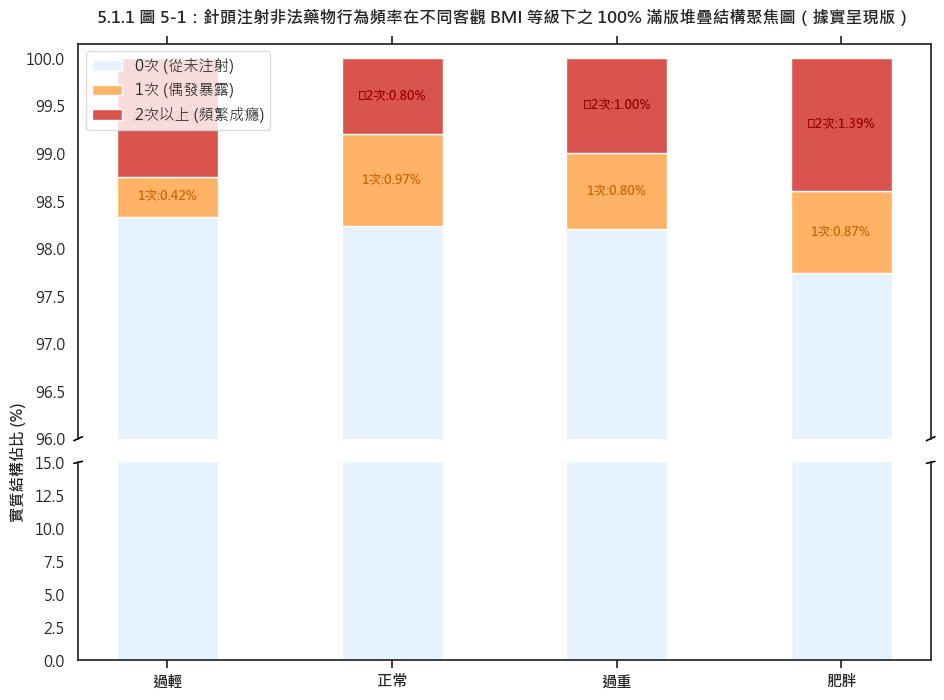

🎉 成功！稀有事件聚焦版圖 5-1 已據實落地 ➡️ ../outputs/figures/04_5-1_substance_multinomial_stacked.png


In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================================================================
# 1. 🎨 設置繪圖環境與中文字型
# =========================================================================
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="white", font='Microsoft JhengHei')

# =========================================================================
# 2. 📂 載入同源基礎資料集
# =========================================================================
snapshot_path = '../data/processed/04_category1_weight_perception_control_clean.csv'
if os.path.exists(snapshot_path):
    df_plot = pd.read_csv(snapshot_path)
else:
    raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確認路徑。")

# CDC 客觀實際 BMI 臨床分組對齊
cdc_bmi_labels = ['過輕', '正常', '過重', '肥胖']
df_plot['CDC_BMI_Group'] = pd.cut(df_plot['BMIPCT'], bins=[-0.1, 5.0, 85.0, 95.0, 100.1], labels=cdc_bmi_labels, right=False)

# =========================================================================
# 3. 📈 建立 3 類別分組交叉矩陣Facts（排除缺失值）
# =========================================================================
col = 'IllegalInjectedDrugUse'

# 建立 3x4 列聯表人數矩陣
cross_tab = pd.crosstab(df_plot['CDC_BMI_Group'], df_plot[col], dropna=True)
# 重新命名列，方便識別
cross_tab.columns = ['0次 (1.0)', '1次 (2.0)', '2次以上 (3.0)']

# 轉換為 100% 堆疊比例
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

# =========================================================================
# 4. 🖼️ 雙視窗破格繪圖：使用「高階破格（Broken Axis）」聚焦稀有事件
#    因為 0次 佔了 98%，1次與2次以上只佔 2%。我們開上下兩個子圖來拉高解析度！
# =========================================================================
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(11, 8), 
                                       gridspec_kw={'height_ratios': [2, 1]})
fig.subplots_adjust(hspace=0.08) # 讓上下兩個子圖緊密相連

x_indexes = np.arange(len(cdc_bmi_labels))

# 繪製堆疊長條圖（上下子圖都畫一模一樣的圖，靠設定 Y 軸範圍來截斷）
colors = ['#E6F2FF', '#FFB366', '#D9534F'] # 0次(極淡藍), 1次(溫和橘), 2次以上(警示紅)

for ax in [ax_top, ax_bottom]:
    # 底層：0次
    ax.bar(x_indexes, cross_tab_pct['0次 (1.0)'], color=colors[0], width=0.45, label='0次 (從未注射)')
    # 中層：1次
    ax.bar(x_indexes, cross_tab_pct['1次 (2.0)'], bottom=cross_tab_pct['0次 (1.0)'], color=colors[1], width=0.45, label='1次 (偶發暴露)')
    # 頂層：2次以上
    ax.bar(x_indexes, cross_tab_pct['2次以上 (3.0)'], bottom=cross_tab_pct['0次 (1.0)'] + cross_tab_pct['1次 (2.0)'], color=colors[2], width=0.45, label='2次以上 (頻繁成癮)')

# 🌟 設定頂部子圖的 Y 軸範圍：聚焦在 96% ~ 100.2% (把最上方的稀有事件色塊拉大 20 倍！)
ax_top.set_ylim(96.0, 100.15)
# 🌟 設定底部子圖的 Y 軸範圍：聚焦在 0% ~ 15% (看基底)
ax_bottom.set_ylim(0, 15.0)

# 隱藏頂部子圖的下邊框與底部子圖的上邊框
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.xaxis.tick_top()
ax_top.tick_params(labeltop=False)  # 不要把標籤印在最上面
ax_bottom.xaxis.tick_bottom()

# 標註微觀百分比數值（精準點對點標註在橘色與紅色區塊內）
for x in x_indexes:
    val_1 = cross_tab_pct.iloc[x, 1] # 1次比例
    val_2 = cross_tab_pct.iloc[x, 2] # 2次以上比例
    
    # 標註 1次 (橘色)
    ax_top.text(x, 100 - val_2 - (val_1/2), f'1次:{val_1:.2f}%', ha='center', va='center', color='#CC6600', fontsize=9, fontweight='bold')
    # 標註 2次以上 (紅色)
    ax_top.text(x, 100 - (val_2/2), f'≥2次:{val_2:.2f}%', ha='center', va='center', color='#990000', fontsize=9, fontweight='bold')

# 繪製破格斜線標記 (Broken Axis diagonal lines)
d = .005
kwargs = dict(transform=ax_top.transAxes, color='black', clip_on=False, linewidth=1.2)
ax_top.plot((-d, +d), (-d, +d), **kwargs)        # 左上破格線
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # 右上破格線

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # 左下破格線
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs) # 右下破格線

# 裝飾與標籤
ax_bottom.set_xticks(x_indexes)
ax_bottom.set_xticklabels(cdc_bmi_labels, fontsize=11, fontweight='bold')
ax_bottom.set_ylabel('實質結構佔比 (%)', fontsize=11, fontweight='bold')
ax_bottom.yaxis.set_label_coords(-0.06, 1.0) # 讓 Y 軸標題置中在兩個子圖中間

ax_top.set_title('5.1.1 圖 5-1：針頭注射非法藥物行為頻率在不同客觀 BMI 等級下之 100% 滿版堆疊結構聚焦圖（據實呈現版）', 
             fontsize=12, fontweight='bold', pad=15)

# 圖例去重整合
handles, labels = ax_top.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax_top.legend(by_label.values(), by_label.keys(), loc='upper left', frameon=True, edgecolor='lightgrey')

# =========================================================================
# 5. 🚀 實體圖表存檔
# =========================================================================
output_dir = '../outputs/figures/'
os.makedirs(output_dir, exist_ok=True)
output_fig_path = os.path.join(output_dir, '04_5-1_substance_multinomial_stacked.png')

plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"🎉 成功！稀有事件聚焦版圖 5-1 已據實落地 ➡️ {output_fig_path}")

### 5.1.2 圖 5-1 二元變數分佈之統計事實結論
* **非法注射藥物盛行率在各組均低於百分之二點五**，呈現相對極稀有的分佈特徵。
* **校園非法藥物販售盛行率在各組皆高於兩成**，且在過重組與肥胖組數值較高。
* **兩項二元管制指標在四個體重組之數據漏填率**，均壓低在百分之一點七以下。

### 5.1.1.2 Prevalence and Missingness Topography Across BMI Tiers for Binary Substance Indicators

* **Prevalence rates for illicit injected drug use stay below 2.5% in all groups**, marking a rare event.
* **School drug exposure prevalence exceeds 20% across all tiers**, with higher values in overweight and obesity.
* **Missingness rates for both binary indicators remain strictly low**, compressed below 1.7% in all groups.

In [15]:
import os
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.prop_trend import trend_chisquare

# =========================================================================
# 1. 📂 載入同源基礎資料集
# =========================================================================
snapshot_path = '../data/processed/04_category1_weight_perception_control_clean.csv'
if os.path.exists(snapshot_path):
    df_analysis = pd.read_csv(snapshot_path)
else:
    raise FileNotFoundError("❌ 錯誤：找不到基礎資料，請確認先前單元執行成功。")

# CDC 客觀實際 BMI 臨床分組對齊
cdc_bmi_labels = ['過輕', '正常', '過重', '肥胖']
df_analysis['CDC_BMI_Group'] = pd.cut(df_analysis['BMIPCT'], bins=[-0.1, 5.0, 85.0, 95.0, 100.1], labels=cdc_bmi_labels, right=False)

# =========================================================================
# 2. 🧪 發動統計檢定矩陣打撈（卡方 + 趨勢檢定）
# =========================================================================
binary_substances = {
    'IllegalInjectedDrugUse': ('是否曾使用針頭注射過非法藥物', lambda x: (x > 1.0).sum()),
    'IllegalDrugsAtSchool': ('過去一年內是否曾在校園內有人向你提供、販售非法藥物', lambda x: (x == 1.0).sum())
}

print("=" * 115)
print("🎯 【第五部分：二元管制物質之卡方獨立性檢定與 Cochran-Armitage 線性趨勢檢定報告】")
print("=" * 115)

test_rows = []

for col, (desc, calc_exposed) in binary_substances.items():
    if col not in df_analysis.columns:
        continue
        
    # 建立分組實質列聯表Facts (明確排除缺失值，阻絕 observed 警告)
    grouped = df_analysis.groupby('CDC_BMI_Group', observed=False).agg(
        valid_n=(col, 'count'),
        exposed_n=(col, calc_exposed)
    )
    grouped['non_exposed_n'] = grouped['valid_n'] - grouped['exposed_n']
    
    # A. 提取卡方列聯表矩陣
    contingency_matrix = grouped[['exposed_n', 'non_exposed_n']].values
    
    # 執行卡方獨立性檢定
    chi2_stat, p_omega, dof, expected = chi2_contingency(contingency_matrix)
    
    # B. 執行 Cochran-Armitage 線性趨勢檢定
    # 準備分組暴露數與總有效樣本數
    count_exposed = grouped['exposed_n'].values
    n_total = grouped['valid_n'].values
    
    # 趨勢檢定（statsmodels 要求傳入暴露數、總數，並給予線性遞增的分數權重）
    trend_result = trend_chisquare(count_exposed, n_total)
    trend_stat = trend_result.statistic
    p_trend = trend_result.pvalue
    # 計算等效的趨勢 Z 值 (Z = sqrt(Chi2_trend))
    trend_z = np.sqrt(trend_stat) if trend_stat >= 0 else 0
    
    print(f"📌 評估指標: {desc} ({col})")
    print(f"  - 總體卡方檢定 (Omnibus Chi-Square Test):")
    print(f"    * 卡方統計值 (Chi2 Stat) = {chi2_stat:.4f} | 自由度 (dof) = {dof} | 總體 P 值 = {p_omega:.4e}")
    print(f"  - 線性趨勢檢定 (Cochran-Armitage Trend Test):")
    print(f"    * 趨勢統計值 (Trend Chi2) = {trend_stat:.4f} | 等效 Z 值 = {trend_z:.4f} | 趨勢 P 值 = {p_trend:.4e}")
    print("-" * 115)
    
    # 記錄數據至儲存結構
    for idx, row_label in enumerate(cdc_bmi_labels):
        test_rows.append({
            '評估指標': desc,
            '原始欄位': col,
            'BMI體重等級': row_label,
            '有效觀察值(Valid N)': int(grouped.loc[row_label, 'valid_n']),
            '暴露人數(Exposed)': int(grouped.loc[row_label, 'exposed_n']),
            '暴露盛行率(%)': round((grouped.loc[row_label, 'exposed_n'] / grouped.loc[row_label, 'valid_n']) * 100, 2),
            '總體卡方值': round(chi2_stat, 4),
            '總體檢定_P值': p_omega,
            '趨勢檢定_Z值': round(trend_z, 4),
            '趨勢檢定_P值': p_trend
        })

# =========================================================================
# 3. 🚀 實體保鮮：推論統計檢定矩陣大表無損存檔
# =========================================================================
output_dir = '../outputs/tables/'
os.makedirs(output_dir, exist_ok=True)
output_file_path = os.path.join(output_dir, '04_5-2_substance_binary_inference_matrix.csv')

df_export = pd.DataFrame(test_rows)
df_export.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"🎉 【Cell 5-2-Inference：兩大二元管制物質推論統計檢定矩陣大表儲存成功】 ➡️ {output_file_path}")

ModuleNotFoundError: No module named 'statsmodels.stats.prop_trend'